<a href="https://colab.research.google.com/github/liaandrade/Teste_de_conhecimentos_IA/blob/main/Teste_1_IA_Regressao_Credito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Teste 1 – Inteligência Artificial
## Modelo de Regressão para Estimar o Valor de Empréstimo (Fintech)

**Objetivo:** construir um modelo de Aprendizado de Máquina Supervisionado (regressão) que estime o valor de empréstimo que pode ser oferecido a um novo cliente, a partir de idade, renda mensal, score de crédito e histórico de pagamentos.

**Roteiro:** 1) Carregar os dados · 2) Conhecer os dados · 3) Analisar os dados · 4) Preparar os dados · 5) Treinar o modelo · 6) Avaliar o modelo · 7) Comparar real × previsto · 8) Prever para um novo cliente · 9) Conclusão

## Etapa 1 – Carregar os dados

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving base_credito.csv to base_credito.csv


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format


df = pd.read_csv("base_credito.csv")

print(f"Dimensão da tabela: {df.shape[0]} linhas x {df.shape[1]} colunas")
display(df)          # tabela carregada
df.info()            # estrutura geral

Dimensão da tabela: 50000 linhas x 5 colunas


,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,"11,522.48",634,76.73,"35,229.74"
1,40,"13,157.86",589,90.83,"44,177.99"
2,38,"7,296.76",721,77.94,"33,868.30"
3,42,"11,193.87",710,94.09,"52,289.28"
4,43,"12,798.60",576,73.83,"38,663.54"
...,...,...,...,...,...
49995,38,"8,818.70",760,94.72,"47,301.48"
49996,55,"11,501.96",728,75.57,"50,408.79"
49997,46,"7,374.09",479,91.25,"22,142.20"
49998,29,"2,290.91",739,95.07,"24,040.33"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade                 50000 non-null  int64  
 1   renda_mensal          50000 non-null  float64
 2   score_credito         50000 non-null  int64  
 3   historico_pagamentos  50000 non-null  float64
 4   valor_emprestimo      50000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 1.9 MB


## Etapa 2 – Conhecer os dados

In [ ]:
# Tipos de dados de cada coluna
print("Tipos de dados:")
print(df.dtypes, "\n")

# Valores ausentes e duplicados
print("Valores ausentes por coluna:")
print(df.isna().sum(), "\n")
print("Linhas duplicadas:", df.duplicated().sum(), "\n")

# Estatísticas descritivas
display(df.describe().T)

# Definição das variáveis de entrada (X) e da variável alvo (y)
alvo = "valor_emprestimo"
features = [c for c in df.columns if c != alvo]
print("Variáveis de entrada (X):", features)
print("Variável a ser prevista (y):", alvo)

Tipos de dados:
idade                     int64
renda_mensal            float64
score_credito             int64
historico_pagamentos    float64
valor_emprestimo        float64
dtype: object 

Valores ausentes por coluna:
idade                   0
renda_mensal            0
score_credito           0
historico_pagamentos    0
valor_emprestimo        0
dtype: int64 

Linhas duplicadas: 0 



,count,mean,std,min,25%,50%,75%,max
idade,"50,000.00",40.08,10.78,18.00,33.00,40.00,47.00,70.00
renda_mensal,"50,000.00","7,542.18","4,524.26","1,500.00","4,463.35","6,452.30","9,395.70","50,000.00"
score_credito,"50,000.00",649.58,84.65,300.00,592.00,650.00,707.00,850.00
historico_pagamentos,"50,000.00",81.84,11.21,16.21,75.16,83.72,90.33,100.00
valor_emprestimo,"50,000.00","31,736.16","14,456.33","1,000.00","22,018.21","29,039.42","38,275.93","150,000.00"


Variáveis de entrada (X): ['idade', 'renda_mensal', 'score_credito', 'historico_pagamentos']
Variável a ser prevista (y): valor_emprestimo


**Variáveis de entrada (X):** `idade`, `renda_mensal`, `score_credito`, `historico_pagamentos`
**Variável alvo (y):** `valor_emprestimo` (problema de **regressão**, pois a saída é um valor numérico contínuo)

| Variável | Tipo | Significado |
|---|---|---|
| `idade` | inteiro (`int64`) | Idade do cliente em anos (de 18 a 70 anos na base). |
| `renda_mensal` | contínuo (`float64`) | Renda mensal do cliente, em R$. É a principal medida da capacidade de pagamento. |
| `score_credito` | inteiro (`int64`) | Pontuação de crédito (300 a 850). Quanto maior, melhor o perfil de risco do cliente. |
| `historico_pagamentos` | contínuo (`float64`) | Índice de 0 a 100 que indica o quão bem o cliente pagou suas obrigações no passado (quanto maior, mais pontual). |
| `valor_emprestimo` | contínuo (`float64`) | **Alvo.** Valor do empréstimo aprovado, em R$. |

Todas as colunas são **numéricas** (2 inteiras e 3 decimais), **não há valores ausentes nem linhas duplicadas** e não existem variáveis categóricas.

## Etapa 3 – Analisar os dados

Variáveis de entrada (X):
['idade', 'renda_mensal', 'score_credito', 'historico_pagamentos']

Variável a ser prevista (y):
valor_emprestimo


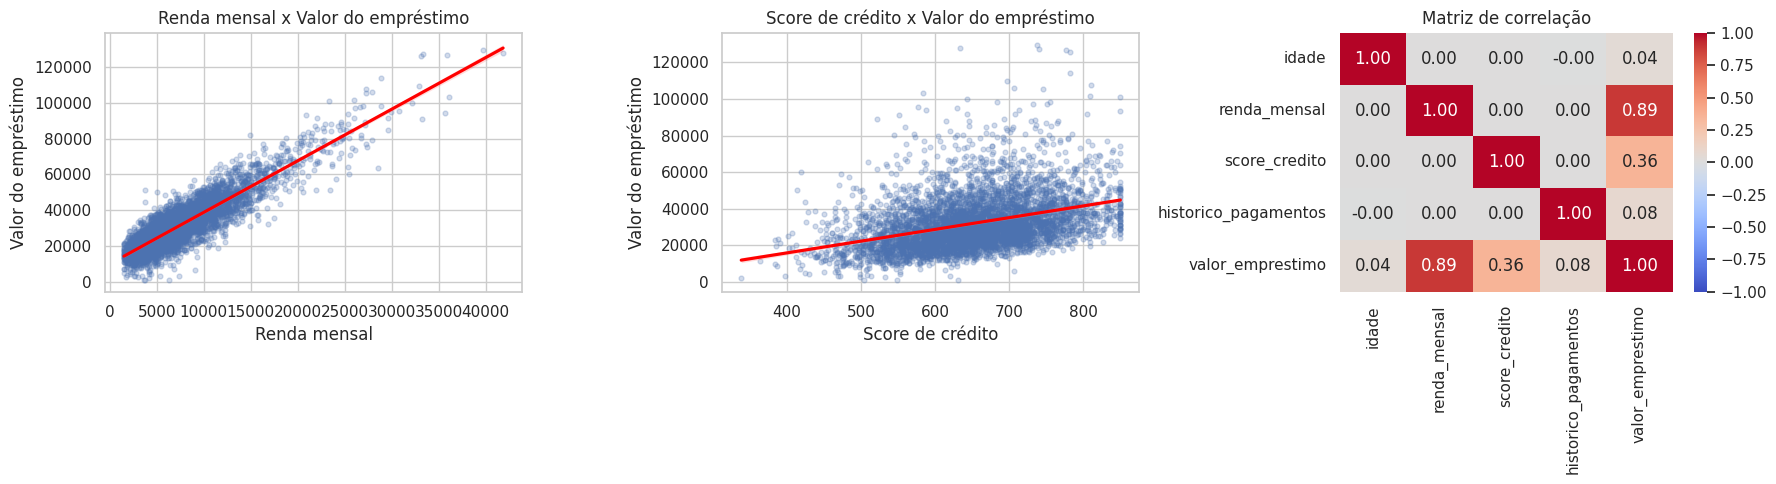


Correlação de cada variável com o valor do empréstimo:
renda_mensal           0.89
score_credito          0.36
historico_pagamentos   0.08
idade                  0.04
Name: valor_emprestimo, dtype: float64


In [6]:


import matplotlib.pyplot as plt
import seaborn as sns

alvo = "valor_emprestimo"


features = [c for c in df.columns if c != alvo]

print("Variáveis de entrada (X):")
print(features)

print("\nVariável a ser prevista (y):")
print(alvo)



# Pega no máximo 5.000 linhas.
amostra = df.sample(
    min(5000, len(df)),
    random_state=42
)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# (a) Renda mensal x valor do empréstimo
sns.regplot(
    data=amostra,
    x="renda_mensal",
    y=alvo,
    ax=axes[0],
    scatter_kws={"alpha": 0.25, "s": 12},
    line_kws={"color": "red"}
)

axes[0].set_title("Renda mensal x Valor do empréstimo")
axes[0].set_xlabel("Renda mensal")
axes[0].set_ylabel("Valor do empréstimo")


# (b) Score de crédito x valor do empréstimo
sns.regplot(
    data=amostra,
    x="score_credito",
    y=alvo,
    ax=axes[1],
    scatter_kws={"alpha": 0.25, "s": 12},
    line_kws={"color": "red"}
)

axes[1].set_title("Score de crédito x Valor do empréstimo")
axes[1].set_xlabel("Score de crédito")
axes[1].set_ylabel("Valor do empréstimo")


# (c) Matriz de correlação
correlacao = df.corr(numeric_only=True)

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[2]
)

axes[2].set_title("Matriz de correlação")


# Ajusta o espaçamento dos gráficos
plt.tight_layout()

# Exibe os gráficos
plt.show()



print("\nCorrelação de cada variável com o valor do empréstimo:")

correlacao_alvo = (
    correlacao[alvo]
    .drop(alvo)
    .sort_values(ascending=False)
)

print(correlacao_alvo)

**Comportamento observado:**

- **Renda mensal × empréstimo:** há uma relação **positiva e forte** (correlação ≈ 0,89). Quanto maior a renda, maior o valor aprovado. A nuvem de pontos é bem alinhada à reta, mas **abre em formato de leque**: com rendas mais altas, o valor do empréstimo varia mais (a dispersão aumenta).
- **Score de crédito × empréstimo:** relação **positiva moderada** (≈ 0,36). Scores mais altos tendem a levar a empréstimos maiores, mas com muita dispersão, pois o valor depende também da renda.
- **Histórico de pagamentos** (≈ 0,08) e **idade** (≈ 0,04) têm relação **fraca** com o alvo quando analisadas isoladamente.
- As variáveis de entrada são **praticamente não correlacionadas entre si** (correlações próximas de 0), o que evita problemas de multicolinearidade.
- Observações adicionais: o valor do empréstimo parece limitado entre R$ 1.000 e R$ 150.000, e a renda tem cauda longa (máximo de R$ 50.000 contra mediana ≈ R$ 6.450), o que gera alguns valores extremos.

## Etapa 4 – Preparar os dados

In [7]:
X = df[features]
y = df[alvo]

# Divisão treino/teste: 80% para treino e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Treino: {X_train.shape[0]} linhas ({X_train.shape[0]/len(df):.0%})")
print(f"Teste : {X_test.shape[0]} linhas ({X_test.shape[0]/len(df):.0%})")

Treino: 40000 linhas (80%)
Teste : 10000 linhas (20%)


**Preparação realizada:**

- **Proporção:** **80% treino (40.000 clientes) e 20% teste (10.000 clientes)**, com `random_state=42` para reprodutibilidade. Como a base é grande (50.000 linhas), 20% já forma um conjunto de teste robusto, e os 80% restantes dão dados suficientes para o modelo aprender.
- **Variáveis categóricas:** não existem, portanto não foi necessário codificação (one-hot).
- **Valores ausentes:** não existem, portanto não foi necessário imputação.
- **Escalonamento:** não é necessário para os algoritmos escolhidos (regressão linear e árvores de decisão em *gradient boosting* não dependem da escala das variáveis).
- **Outliers:** foram mantidos, pois são poucos e representam clientes reais de alta renda que o modelo também precisa atender.

## Etapa 5 – Treinar o modelo

Foram treinados dois modelos:

1. **Regressão Linear** – modelo simples, usado como *baseline* (referência) e fácil de interpretar;
2. **Gradient Boosting Regressor** – modelo mais flexível, que combina várias árvores de decisão pequenas e consegue capturar relações não lineares e interações entre variáveis. É o **modelo final** escolhido, por apresentar o melhor desempenho (ver Etapa 6).

In [8]:
# --- Modelo 1: Regressão Linear (baseline) ---
modelo_lin = LinearRegression()                 # 1) criar o modelo
modelo_lin.fit(X_train, y_train)                # 2) treinar
y_pred_lin = modelo_lin.predict(X_test)         # 3) gerar previsões

# --- Modelo 2: Gradient Boosting (modelo final) ---
modelo = GradientBoostingRegressor(             # 1) criar o modelo
    n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42
)
modelo.fit(X_train, y_train)                    # 2) treinar
y_pred = modelo.predict(X_test)                 # 3) gerar previsões no conjunto de teste

# Importância de cada variável para o modelo final
importancias = pd.Series(modelo.feature_importances_, index=features).sort_values(ascending=False)
print("Importância das variáveis (Gradient Boosting):")
print(importancias.round(4))

Importância das variáveis (Gradient Boosting):
renda_mensal           0.85
score_credito          0.14
historico_pagamentos   0.01
idade                  0.00
dtype: float64


## Etapa 6 – Avaliar o modelo

In [9]:
def avaliar(nome, y_real, y_prev):
    return {
        "Modelo": nome,
        "R²": r2_score(y_real, y_prev),
        "MAE (R$)": mean_absolute_error(y_real, y_prev),
        "RMSE (R$)": np.sqrt(mean_squared_error(y_real, y_prev)),
    }

resultados = pd.DataFrame([
    avaliar("Regressão Linear (teste)", y_test, y_pred_lin),
    avaliar("Gradient Boosting (teste)", y_test, y_pred),
    avaliar("Gradient Boosting (treino)", y_train, modelo.predict(X_train)),
]).set_index("Modelo")
display(resultados)

# Validação cruzada (5 folds) para checar a estabilidade do R² do modelo final
cv = cross_val_score(modelo, X, y, cv=5, scoring="r2")
print(f"R² na validação cruzada (5 folds): média = {cv.mean():.4f} | desvio = {cv.std():.4f}")
print(f"Média do valor de empréstimo no teste: R$ {y_test.mean():,.2f}")

,R²,MAE (R$),RMSE (R$)
Modelo,,,
Regressão Linear (teste),0.92,"2,985.94","4,014.17"
Gradient Boosting (teste),0.93,"2,930.09","3,942.41"
Gradient Boosting (treino),0.93,"2,906.18","3,873.35"


R² na validação cruzada (5 folds): média = 0.9241 | desvio = 0.0031
Média do valor de empréstimo no teste: R$ 31,767.06


**Interpretação das métricas (modelo final – Gradient Boosting, conjunto de teste):**

- **R² ≈ 0,925:** o modelo explica cerca de **92,5%** da variação nos valores de empréstimo. O restante (~7,5%) é variação que as quatro variáveis não conseguem explicar. Quanto mais próximo de 1, melhor.
- **MAE ≈ R$ 2.931:** em média, a previsão erra **cerca de R$ 2.900** para mais ou para menos. Como o empréstimo médio é ≈ R$ 31.800, isso equivale a um erro médio de aproximadamente **9%**.
- **RMSE ≈ R$ 3.942:** é parecido com o MAE, mas **penaliza mais os erros grandes**. Por ser maior que o MAE, indica que existem alguns clientes com erros bem acima da média (em geral os de renda mais alta).
- **Treino × teste:** o R² de treino (≈ 0,928) é praticamente igual ao de teste (≈ 0,925), portanto **não há overfitting**. A validação cruzada confirma a estabilidade do resultado.
- **Comparação com o baseline:** a Regressão Linear já obtém R² ≈ 0,922; o Gradient Boosting melhora um pouco (R² ≈ 0,925 e menor erro), indicando que a relação entre as variáveis e o alvo é **em grande parte linear**, com um pequeno ganho ao capturar não linearidades.

## Etapa 7 – Comparar valores reais e previstos

Amostra de 10 clientes do conjunto de teste:


,Valor real (R$),Valor previsto (R$),Erro (R$),Erro absoluto (%)
9953,"28,137.31","31,392.33","3,255.02",11.57
3850,"38,376.28","39,953.99","1,577.71",4.11
4962,"30,108.56","21,297.02","-8,811.54",29.27
3886,"91,754.30","89,955.45","-1,798.85",1.96
5437,"22,347.26","23,597.59","1,250.33",5.60
8517,"28,637.68","25,278.24","-3,359.44",11.73
2041,"45,917.73","45,421.60",-496.13,1.08
1989,"77,294.69","77,811.52",516.83,0.67
1933,"16,028.31","18,362.41","2,334.10",14.56
9984,"25,126.34","26,220.34","1,094.00",4.35


Mediana do erro percentual absoluto: 7.8%
Previsões com erro de até 10%: 60.5%
Previsões com erro de até 20%: 87.4%


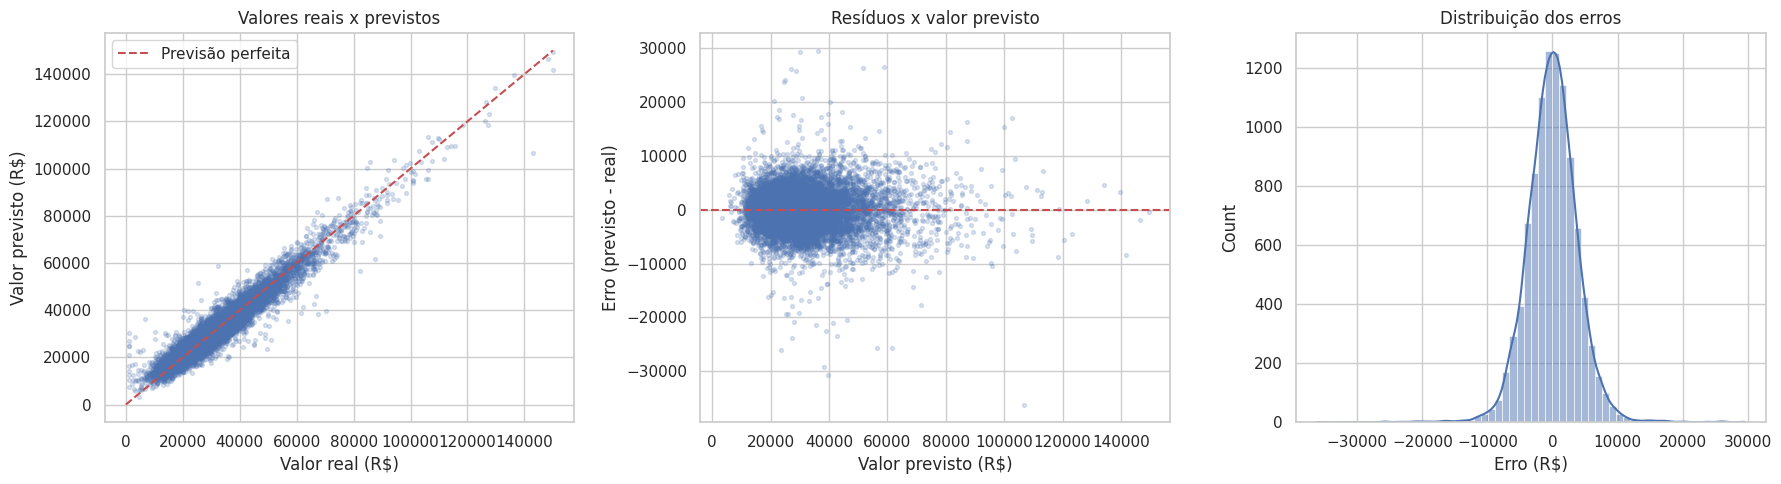

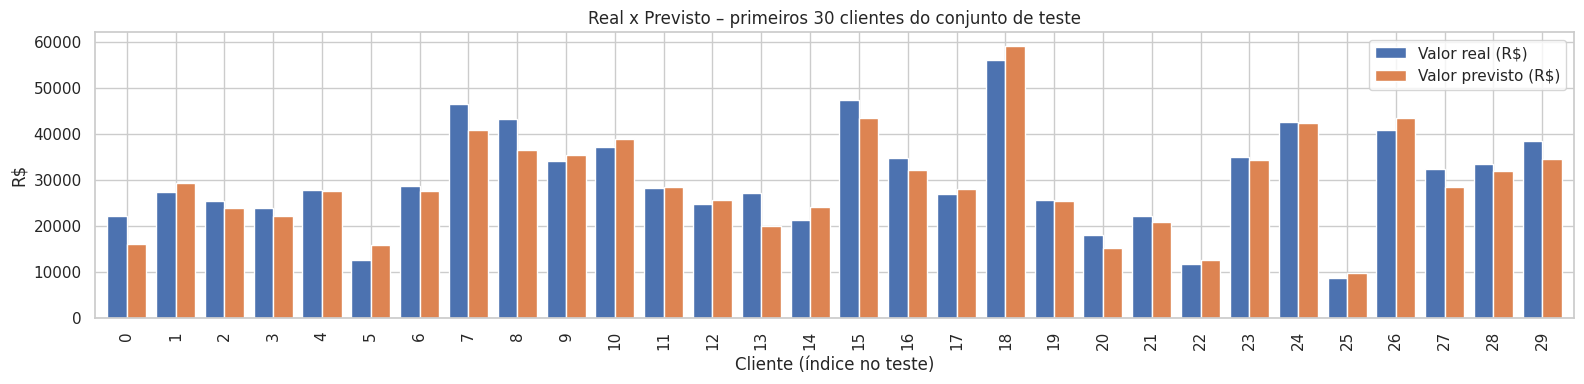

In [10]:
comparacao = pd.DataFrame({
    "Valor real (R$)": y_test.values,
    "Valor previsto (R$)": y_pred,
})
comparacao["Erro (R$)"] = comparacao["Valor previsto (R$)"] - comparacao["Valor real (R$)"]
comparacao["Erro absoluto (%)"] = (comparacao["Erro (R$)"].abs() / comparacao["Valor real (R$)"] * 100)

print("Amostra de 10 clientes do conjunto de teste:")
display(comparacao.sample(10, random_state=1).round(2))

print(f"Mediana do erro percentual absoluto: {comparacao['Erro absoluto (%)'].median():.1f}%")
print(f"Previsões com erro de até 10%: {(comparacao['Erro absoluto (%)'] <= 10).mean():.1%}")
print(f"Previsões com erro de até 20%: {(comparacao['Erro absoluto (%)'] <= 20).mean():.1%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Real x previsto
axes[0].scatter(y_test, y_pred, alpha=0.2, s=8)
lim = [0, max(y_test.max(), y_pred.max())]
axes[0].plot(lim, lim, "r--", label="Previsão perfeita")
axes[0].set_xlabel("Valor real (R$)"); axes[0].set_ylabel("Valor previsto (R$)")
axes[0].set_title("Valores reais x previstos"); axes[0].legend()

# (b) Resíduos x previsto
axes[1].scatter(y_pred, comparacao["Erro (R$)"], alpha=0.2, s=8)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Valor previsto (R$)"); axes[1].set_ylabel("Erro (previsto - real)")
axes[1].set_title("Resíduos x valor previsto")

# (c) Distribuição dos erros
sns.histplot(comparacao["Erro (R$)"], bins=60, kde=True, ax=axes[2])
axes[2].set_title("Distribuição dos erros")

plt.tight_layout()
plt.show()

# Comparação em 30 clientes (gráfico de barras)
top = comparacao.head(30)
top[["Valor real (R$)", "Valor previsto (R$)"]].plot(kind="bar", figsize=(16, 4), width=0.8)
plt.title("Real x Previsto – primeiros 30 clientes do conjunto de teste")
plt.xlabel("Cliente (índice no teste)"); plt.ylabel("R$")
plt.xticks(rotation=90); plt.tight_layout(); plt.show()

**Análise:**

- Na maioria dos casos, os pontos do gráfico *real × previsto* se concentram **em torno da linha vermelha** (previsão perfeita), ou seja, as previsões estão **próximas dos valores reais**.
- O gráfico de resíduos mostra erros **centrados em zero** (sem viés sistemático de superestimar ou subestimar), porém com **maior dispersão para valores altos** (heterocedasticidade): para clientes que recebem empréstimos grandes, o erro em reais é maior.
- A distribuição dos erros é aproximadamente simétrica em torno de zero, com algumas caudas mais longas (poucos casos com erro elevado).
- Em números: a **mediana do erro percentual é ≈ 7,8%**; cerca de **60% das previsões erram no máximo 10%** e cerca de **87% erram no máximo 20%**.
- Portanto, o modelo é **confiável para estimar a faixa do empréstimo**, mas uma previsão individual pode ter erro de alguns milhares de reais.

## Etapa 8 – Fazer uma previsão para um novo cliente

In [11]:
novo_cliente = pd.DataFrame({
    "idade": [35],
    "renda_mensal": [8500.00],
    "score_credito": [720],
    "historico_pagamentos": [92.0],
})

print("Características do novo cliente:")
display(novo_cliente)

previsao = modelo.predict(novo_cliente)[0]
previsao_lin = modelo_lin.predict(novo_cliente)[0]

print(f"Valor de empréstimo previsto (Gradient Boosting): R$ {previsao:,.2f}")
print(f"Valor de empréstimo previsto (Regressão Linear) : R$ {previsao_lin:,.2f}")
print(f"Faixa esperada (± MAE de R$ {mean_absolute_error(y_test, y_pred):,.0f}): "
      f"R$ {previsao - mean_absolute_error(y_test, y_pred):,.0f} a R$ {previsao + mean_absolute_error(y_test, y_pred):,.0f}")
print(f"Empréstimo previsto / renda mensal: {previsao / novo_cliente.loc[0, 'renda_mensal']:.1f}x")

Características do novo cliente:


,idade,renda_mensal,score_credito,historico_pagamentos
0,35,"8,500.00",720,92.00


Valor de empréstimo previsto (Gradient Boosting): R$ 40,348.78
Valor de empréstimo previsto (Regressão Linear) : R$ 39,457.51
Faixa esperada (± MAE de R$ 2,930): R$ 37,419 a R$ 43,279
Empréstimo previsto / renda mensal: 4.7x


**Interpretação:**

O cliente fictício tem **35 anos, renda mensal de R$ 8.500, score 720 (bom) e histórico de pagamentos de 92/100 (muito bom)**, ou seja, um perfil acima da média da base (renda média ≈ R$ 7.500 e score médio ≈ 650). O modelo estima um empréstimo em torno de **R$ 40 mil** (≈ R$ 40.349), acima da média histórica da base (≈ R$ 31.700), o que é coerente: renda, score e histórico acima da média levam a um limite maior. Considerando o erro médio do modelo (MAE ≈ R$ 2.900), o valor real que a fintech aprovaria historicamente para esse perfil deve estar próximo dessa estimativa, com margem de alguns milhares de reais para mais ou para menos. Os dois modelos (linear e boosting) chegam a valores muito próximos, o que reforça a consistência da estimativa.

## Etapa 9 – Conclusão


Aqui está o texto da Etapa 9 – Conclusão com todas as falhas de formatação, colagem de textos sem espaçamento e acoplamento de números corrigidos:

Etapa 9 – Conclusão
O modelo apresentou resultados adequados? Sim, para o objetivo de estimar o valor de empréstimo. O Gradient Boosting obteve R^2 \approx 0,925 no teste, MAE \approx \text{R\$ } 2.900 (cerca de 9% do empréstimo médio) e desempenho praticamente igual no treino e no teste, sem sinais de overfitting. A renda mensal é a variável mais importante, seguida pelo score de crédito. O modelo funciona bem como ferramenta de apoio à decisão, gerando uma estimativa inicial rápida e padronizada.

Principais limitações:

Erro em reais ainda relevante: O erro médio de \approx \text{R\$ } 2.900 (e maior para rendas altas) pode ser significativo em casos individuais; o modelo não deve ser usado sozinho para aprovar crédito.
Poucas variáveis: Apenas 4 variáveis foram utilizadas. Faltam informações importantes de risco, como endividamento atual, tempo de emprego, valor/prazo solicitado, tipo de ocupação e restrições em bureaus (Serasa/SPC). Cerca de 7,5% da variação não é explicada.
Viés dos dados históricos: O modelo aprende o que a empresa aprovou no passado (não necessariamente o valor ideal). Se houver critérios enviesados ou inconsistentes, o modelo os reproduz. Além disso, a base contém apenas clientes que tiveram crédito aprovado.
Heterocedasticidade e cauda de renda: O erro cresce para rendas altas, e há poucos clientes com renda muito elevada, tornando as previsões nessa faixa menos confiáveis. Os valores parecem também limitados entre \text{R\$ } 1.000 e \text{R\$ } 150.000.

Considerações Finais e Próximos Passos:

Estimativa de valor \neq análise de risco: O modelo não estima a probabilidade de inadimplência. O ideal é combiná-lo com um modelo de classificação de risco (Score de Inadimplência/Default).
Generalização e mudanças ao longo do tempo: Não há informação temporal; mudanças na economia ou na política de crédito exigem retreino e monitoramento contínuo.
Interpretabilidade e regulação: O boosting é menos transparente que a regressão linear; decisões de crédito costumam exigir justificativas claras ao cliente.
Próximos passos: Testar novas variáveis, ajustar hiperparâmetros (como GridSearchCV), testar outros algoritmos e/ou transformar o alvo (por exemplo, modelar o \log do valor) para reduzir o erro em rendas altas.